In [70]:
import pandas as pd
import matplotlib.pyplot as plt


In [71]:
df = pd.read_csv('../ncbi_562_data.csv')
df = df[df['is_usa_based'] == 1]
df['collection_year'] = pd.to_numeric(df['collection_year'], errors='coerce')
df = df[df['collection_year'] >= 2005]
df = df[df['month'].notna()]
#convert collection_year to str
df['collection_year'] = df['collection_year'].astype(str)
df['collection_year'] = df['collection_year'].str[:4]

In [72]:
df.head(10)

,genome,geo_loc_name,collection_date,strain,host,serotype,isolate,isolation_source,source_type,geo_loc_name_is_missing,is_usa_based,usa_state,new_isolation_source,collection_year,month,nors_primary_mode_map
860,GCA_000397505.1,"USA: Seattle, WA",2005-03-03,TOP2386,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,3.0,NaN
861,GCA_000397525.1,"USA: Seattle, WA",2005-03-03,TOP2396-1,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,3.0,NaN
862,GCA_000397545.1,"USA: Seattle, WA",2005-03-03,TOP2396-2,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,3.0,NaN
863,GCA_000397565.1,"USA: Seattle, WA",2005-03-03,TOP2396-3,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,3.0,NaN
864,GCA_000397585.1,"USA: Seattle, WA",2005-04-01,TOP2515,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,4.0,NaN
865,GCA_000397605.1,"USA: Seattle, WA",2005-04-01,TOP2522-1,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,4.0,NaN
866,GCA_000397625.1,"USA: Seattle, WA",2005-04-27,TOP2652,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,4.0,NaN
867,GCA_000397645.1,"USA: Seattle, WA",2005-04-27,TOP2662-1,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,4.0,NaN
868,GCA_000397665.1,"USA: Seattle, WA",2005-04-27,TOP2662-2,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,4.0,NaN
869,GCA_000397685.1,"USA: Seattle, WA",2005-04-27,TOP2662-3,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,4.0,NaN


In [73]:
df['collection_year'].value_counts()

collection_year
2019    11367
2021     9521
2018     8894
2022     8803
2020     8665
2017     5200
2016     4387
2015     3773
2014     1894
2023     1799
2013     1356
2012      857
2006      482
2011      462
2007      402
2010      393
2009      316
2005      258
2008      181
Name: count, dtype: int64

In [74]:

#recode months to be 01, 02, ..., 12
df['month'] = df['month'].astype(int)
df['month'] = df['month'].apply(lambda x: f"{x:02d}")
df['month'].value_counts()

month
07    8440
08    8050
06    7212
09    6494
10    5986
05    5946
11    5171
01    4924
04    4601
03    4386
12    4026
02    3774
Name: count, dtype: int64

In [75]:
df['year_and_month'] = df['collection_year'] + '-' + df['month']
df.head(10)



,genome,geo_loc_name,collection_date,strain,host,serotype,isolate,isolation_source,source_type,geo_loc_name_is_missing,is_usa_based,usa_state,new_isolation_source,collection_year,month,nors_primary_mode_map,year_and_month
860,GCA_000397505.1,"USA: Seattle, WA",2005-03-03,TOP2386,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,03,NaN,2005-03
861,GCA_000397525.1,"USA: Seattle, WA",2005-03-03,TOP2396-1,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,03,NaN,2005-03
862,GCA_000397545.1,"USA: Seattle, WA",2005-03-03,TOP2396-2,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,03,NaN,2005-03
863,GCA_000397565.1,"USA: Seattle, WA",2005-03-03,TOP2396-3,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,03,NaN,2005-03
864,GCA_000397585.1,"USA: Seattle, WA",2005-04-01,TOP2515,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,04,NaN,2005-04
865,GCA_000397605.1,"USA: Seattle, WA",2005-04-01,TOP2522-1,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,04,NaN,2005-04
866,GCA_000397625.1,"USA: Seattle, WA",2005-04-27,TOP2652,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,04,NaN,2005-04
867,GCA_000397645.1,"USA: Seattle, WA",2005-04-27,TOP2662-1,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,04,NaN,2005-04
868,GCA_000397665.1,"USA: Seattle, WA",2005-04-27,TOP2662-2,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,04,NaN,2005-04
869,GCA_000397685.1,"USA: Seattle, WA",2005-04-27,TOP2662-3,Homo sapiens,NaN,NaN,NaN,NaN,False,1.0,WASHINGTON,Uncategorized,2005,04,NaN,2005-04


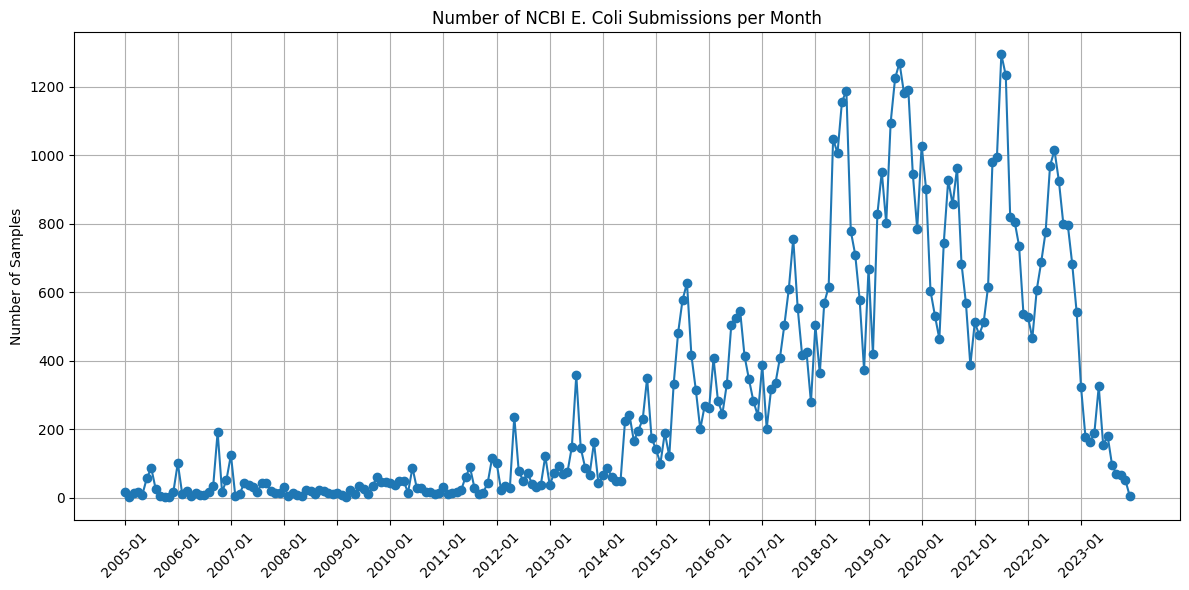

In [76]:
#make a line plot of the value_counts of year_and_month
year_month_counts = df['year_and_month'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
year_month_counts.plot(kind='line', marker='o')
plt.title('Number of NCBI E. Coli Submissions per Month')
plt.ylabel('Number of Samples')
#erase the x-axis label
plt.xlabel('')
plt.xticks(ticks=range(0, len(year_month_counts), 12), labels=year_month_counts.index[::12], rotation=45)
plt.grid()
plt.tight_layout()
plt.savefig('seasonal_ncbi_562.png')
plt.show()


In [77]:
#Similar to the NORS data, we see seasonal peaks during the summer months, and lows during winter months.